<a href="https://colab.research.google.com/github/TeddyAbraham/Ad_ease/blob/main/Ted_Ad_ease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AdEase Case Study

###Introduction
- AdEase is an ads and marketing-based company helping businesses elicit maximum clicks @ minimum cost.
- AdEase is an ad infrastructure to help businesses promote themselves easily, effectively, and economically
-AdEase is trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients.
- By leveraging data science and time series, Ad Ease can forecast page visits for different languages.

In [94]:
# libraries to analyze data
import numpy as np
import pandas as pd

# libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

import re

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)


from statsmodels.tsa.arima.model import ARIMA

In [95]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

sns.set(rc={'figure.figsize':(11.7,8.27)})
!pip install --upgrade --no-cache-dir gdown

In [96]:
!gdown 12SZwjSzzk2NnE8QjMNHGq9-LpYudCEio

train = pd.read_csv('train_1.csv')
train.head()

Downloading...
From (original): https://drive.google.com/uc?id=12SZwjSzzk2NnE8QjMNHGq9-LpYudCEio
From (redirected): https://drive.google.com/uc?id=12SZwjSzzk2NnE8QjMNHGq9-LpYudCEio&confirm=t&uuid=4b7f2cac-849f-4ecf-b6b7-42a56ad7226a
To: /content/train_1.csv
100% 278M/278M [00:03<00:00, 71.1MB/s]


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


#1. Data Loading

Loading the data into Pandas dataframe for easily handling of data



In [97]:
# read the file into a pandas dataframe
df = pd.read_csv('train_1.csv')
# look at the datatypes of the columns
print('*************************************************')
print(df.info())
print('*************************************************\n')
print('*************************************************')
print(f'Shape of the dataset is {df.shape}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of nan/null values in each column: \n{df.isna().sum()}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of unique values in each column: \n{df.nunique()}')
print('*************************************************\n')
print('*************************************************')
print(f'Duplicate entries: \n{df.duplicated().value_counts()}')

*************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB
None
*************************************************

*************************************************
Shape of the dataset is (145063, 551)
*************************************************

*************************************************
Number of nan/null values in each column: 
Page              0
2015-07-01    20740
2015-07-02    20816
2015-07-03    20544
2015-07-04    20654
              ...  
2016-12-27     3701
2016-12-28     3822
2016-12-29     3826
2016-12-30     3635
2016-12-31     3465
Length: 551, dtype: int64
*************************************************

*************************************************
Number of unique values in each column: 
Page          145063
2015-07-01      6898
2015-07-02      6823
2015-07-03      6707
2015-07-04     

In [98]:
# look at the top 20 rows
df.head(5)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [99]:
df.describe()


,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


In [100]:
df.describe(include='object')


,Page
count,145063
unique,145063
top,Francisco_el_matemático_(serie_de_televisión_d...
freq,1


### Insight
- There are 145063 entries with 551 columns, i.e. 145063 wikipedia pages with views for 550 days
- There are null/missing values in each of the dates
- There are no duplicates
- There are 145063 unique wikipedia pages

In [101]:
!qdown 13EPrwUJCX7SltHzSpiIvbX1_viPbvU18

/bin/bash: line 1: qdown: command not found


In [102]:
# read the file containing flag for each date indicating if those dates had a campaign/significant event
exog_en = pd.read_csv('Exog_Campaign_eng')
# look at the datatypes of the columns
print('*************************************************')
print(exog_en.info())
print('*************************************************\n')
print('*************************************************')
print(f'Shape of the dataset is {exog_en.shape}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of nan/null values in each column: \n{exog_en.isna().sum()}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of unique values in each column: \n{exog_en.nunique()}')
print('*************************************************\n')
print('*************************************************')
print(f'Duplicate entries: \n{exog_en.duplicated().value_counts()}')

*************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB
None
*************************************************

*************************************************
Shape of the dataset is (550, 1)
*************************************************

*************************************************
Number of nan/null values in each column: 
Exog    0
dtype: int64
*************************************************

*************************************************
Number of unique values in each column: 
Exog    2
dtype: int64
*************************************************

*************************************************
Duplicate entries: 
True     548
False      2
Name: count, dtype: int64


In [103]:
exog_en.head()

,Exog
0,0
1,0
2,0
3,0
4,0


### Insight
- There are 550 entries corresponding to 550 days in the previous dataset
- There are no null/missing values
- There are 2 unique values - 1 ans 0

# 2. Exploratory Data Analysis
## 2.1. Analysing date columns

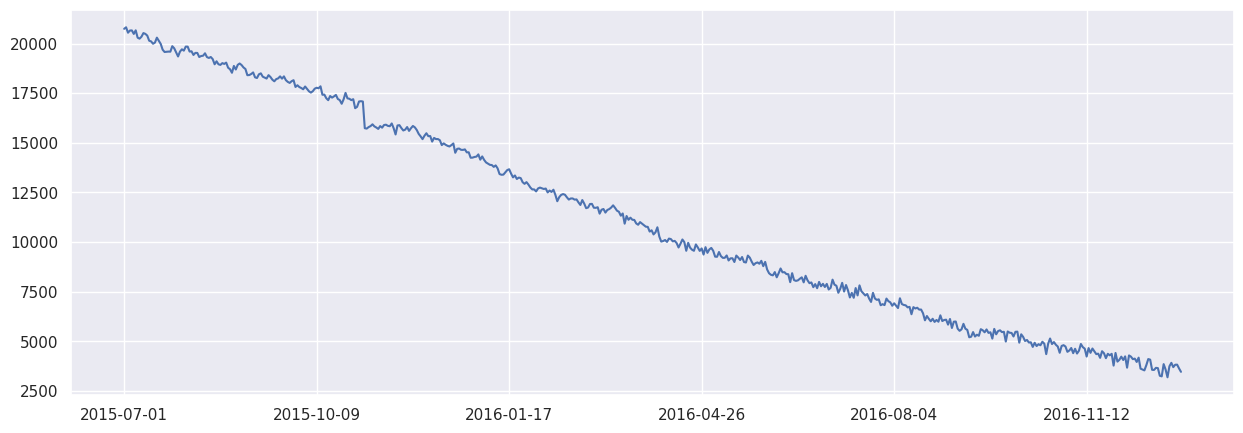

In [104]:
date_columns = df.columns[1:]
df[date_columns].isna().sum().plot(figsize=(15,5))
plt.show()

##Insight
- It can be observed that the null values keep decreasing with dates, indicating that there were no views for these dates
- We can infer that the webpages which were lauched recently will not have view data prior to launch and hence can be filled with 0

In [105]:
df[date_columns] = df.loc[:,date_columns].fillna(0)

In [106]:
df.isna().sum()

,0
Page,0
2015-07-01,0
2015-07-02,0
2015-07-03,0
2015-07-04,0
...,...
2016-12-27,0
2016-12-28,0
2016-12-29,0
2016-12-30,0


## 2.2. Extracting information from Page column

In [107]:
df['Page'].sample(10)


,Page
47570,Liste_der_nach_Punkten_erfolgreichsten_NBA-Spi...
36909,Volleyball_at_the_2016_Summer_Olympics_en.wiki...
64040,NORN9_命運九重奏_zh.wikipedia.org_desktop_all-agents
20766,Help:Extension:Translate/Page_translation_admi...
141751,CNCO_(banda)_es.wikipedia.org_all-access_spider
43168,Gerrit/Troubleshooting_www.mediawiki.org_deskt...
85172,関ジャニ∞_ja.wikipedia.org_desktop_all-agents
106864,林俊杰_zh.wikipedia.org_mobile-web_all-agents
18198,"Дэвис,_Виола_ru.wikipedia.org_mobile-web_all-a..."
16400,Алма-Ата_ru.wikipedia.org_mobile-web_all-agents


The page name contains data in the below format:
SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN
having information about page name, thn domain, device type used to access t e page, aso the request origin(spider or browser age 2.

### 2.2.1. Extracting name

In [108]:
def extract_name(page):
    pattern = r'(.{0,})_(.{2}).wikipedia.org_'
    result = re.findall(pattern, page)
    if len(result) == 1:
        return result[0][0]
    else:
        return 'unknown'
df['name'] = df['Page'].apply(extract_name)

### 2.2.2. Extracting language

In [109]:
def extract_lang(page):
    pattern = r'(.{0,})_(.{2}).wikipedia.org_'
    result = re.findall(pattern, page)
    if len(result) == 1:
        return result[0][1]
    else:
        return 'un'
df['language'] = df['Page'].apply(extract_lang)
print(df['language'].unique())

['zh' 'fr' 'en' 'un' 'ru' 'de' 'ja' 'es']


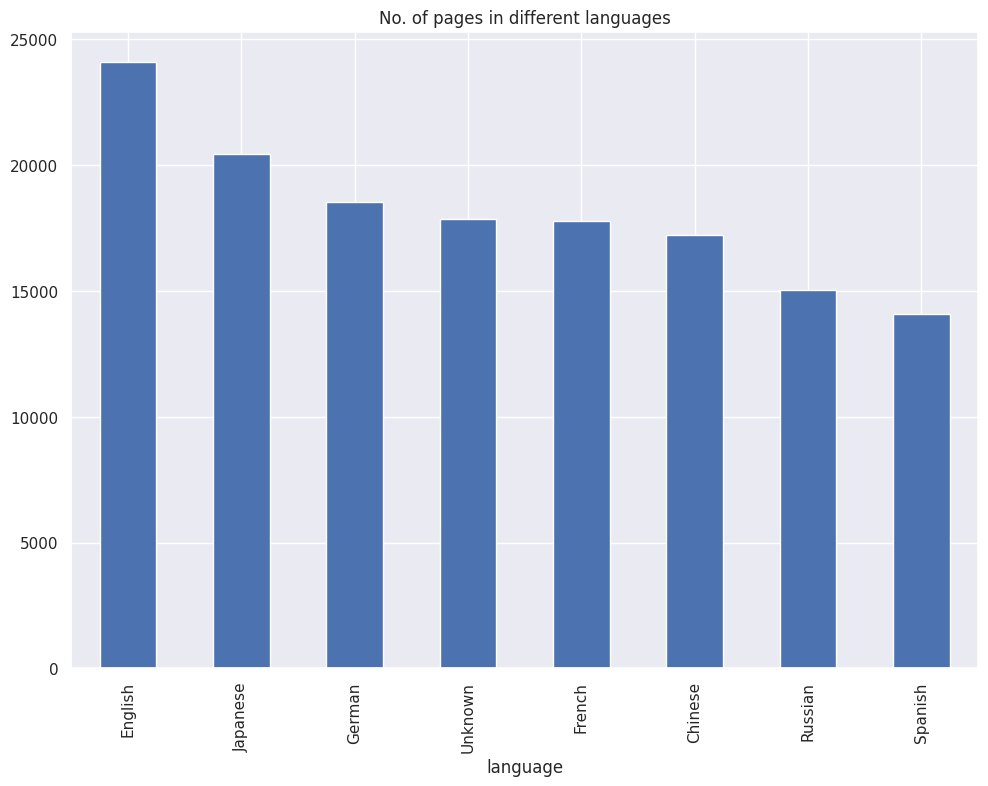

% of pages in different languages


,proportion
language,
English,16.62
Japanese,14.08
German,12.79
Unknown,12.31
French,12.27
Chinese,11.88
Russian,10.36
Spanish,9.70


In [110]:
lang_name_mapping={'zh':'Chinese', 'fr':'French', 'en':'English',
                   'un':'Unknown', 'ru':'Russian', 'de':'German',
                   'ja':'Japanese', 'es':'Spanish'}
df['language'] = df['language'].map(lang_name_mapping)
df['language'].value_counts().plot(kind='bar', title='No. of pages in different languages')
plt.show()
print("% of pages in different languages")
round(df['language'].value_counts(normalize=True)*100,2)

### Insight
- Maximum number of pages, 16.62%, are in English language

### 2.2.3. Extracting access type


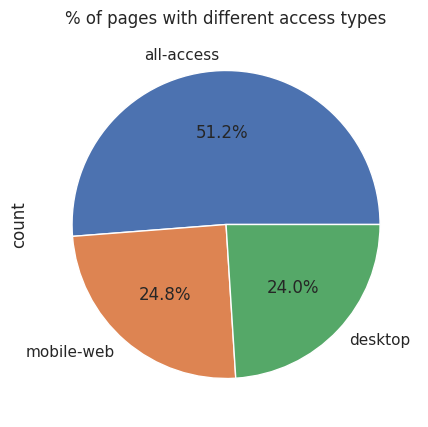

In [111]:
plt.figure(figsize=(5, 5))
df['access_type'] = df['Page'].str.findall(r'all-access|mobile-web|desktop').apply(lambda x: x[0])
df['access_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access types')
plt.show()

### Insight
- Maximum number of pages, 51.2%, have all-access access type

### 2.2.4. Extracting access origin

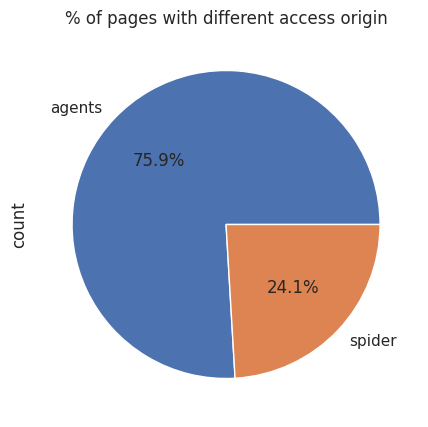

In [112]:
plt.figure(figsize=(5, 5))
df['access_origin'] = df['Page'].str.findall(r'spider|agents').apply(lambda x: x[0])
df['access_origin'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access origin')
plt.show()

### Insight
- Maximum number of pages, 75.9%, have agents access origin

# 3. Aggregate and Pivoting

In [113]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,name,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,Chinese,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,Chinese,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,Chinese,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,Chinese,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,Chinese,all-access,spider


#### Aggregating on language by taking average views per language for each date

In [114]:
df_agg = df.drop(columns=['Page', 'name', 'access_type', 'access_origin']).groupby('language').mean().T.reset_index()
df_agg['index'] = pd.to_datetime(df_agg['index'])
df_agg = df_agg.set_index('index')
df_agg.head()

language,Chinese,English,French,German,Japanese,Russian,Spanish,Unknown
index,,,,,,,,
2015-07-01,240.582042,3513.862203,475.150994,714.968405,580.647056,629.999601,1085.972919,83.479922
2015-07-02,240.941958,3502.511407,478.202000,705.229741,666.672801,640.902876,1037.814557,87.471857
2015-07-03,239.344071,3325.357889,459.837659,676.877231,602.289805,594.026295,954.412680,82.680538
2015-07-04,241.653491,3462.054256,491.508932,621.145145,756.509177,558.728132,896.050750,70.572557
2015-07-05,257.779674,3575.520035,482.557746,722.076185,725.720914,595.029157,974.508210,78.214562


##3.1. Time series plots for all languages

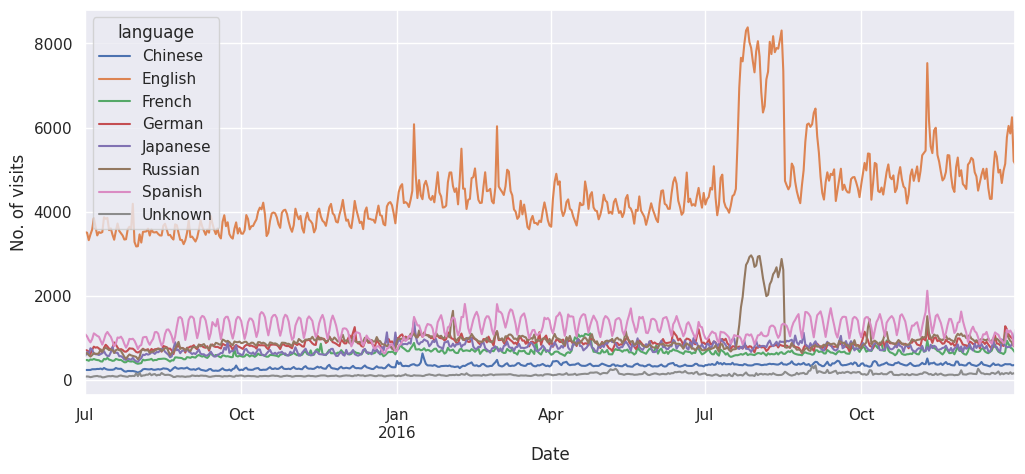

In [115]:
df_agg.plot(figsize=(12,5))
plt.xlabel('Date')
plt.ylabel('No. of visits')
plt.show()

###Insight
- English pages are the most visited pages follwed by Spanish
- English pages have an upward trend in terms of visits
- There is an unusual peak from mid of July to end of August 2016

#4. Stationarity, Detrending, ACF and PACF

##4.1. Stationarity test
**Using Augmented Dickey-Fuller test to check for stationarity**

- H0: The series is not stationary
- H1: The series is stationary

In [116]:
def adfuller_test(time_series):
    p_value = sm.tsa.stattools.adfuller(time_series)[1]
    if(p_value < 0.05):
        print('The time series is stationary')
    else:
        print('The time series is not stationary')

In [117]:
for lang in df_agg.columns:
    print(lang)
    adfuller_test(df_agg[lang])
    print()

Chinese
The time series is not stationary

English
The time series is not stationary

French
The time series is not stationary

German
The time series is not stationary

Japanese
The time series is not stationary

Russian
The time series is stationary

Spanish
The time series is stationary

Unknown
The time series is stationary



###Insight
- Based on the Augmented Dickey-Fuller test, the time series corresponding to Russian and Spanish language page visits are stationary
- The time series corresponding to Chinese, English, French, German and Japanese language page visits are not stationary

**From now on, we will work only on the English language page visit time series**

In [118]:
ts_english = df_agg['English']

Let us look at the English time series along with its exog flag

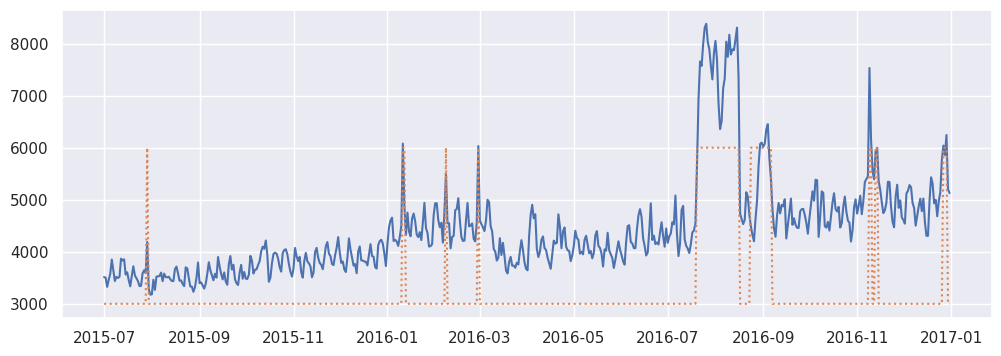

In [119]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_english.index, ts_english)
ax.plot(ts_english.index, (exog_en+1)*3000, ':')
plt.show()

###Insight
- It is very clear from the above plot that the time series looks like an additive time series with linear up trend and linear sesonality
- The unusual spikes in the visits are due to the special events marked by the orange peaks

## 4.2. De-trending and De-seasoning
As the trend is linear, differencing with the previous value should de-trend the time series

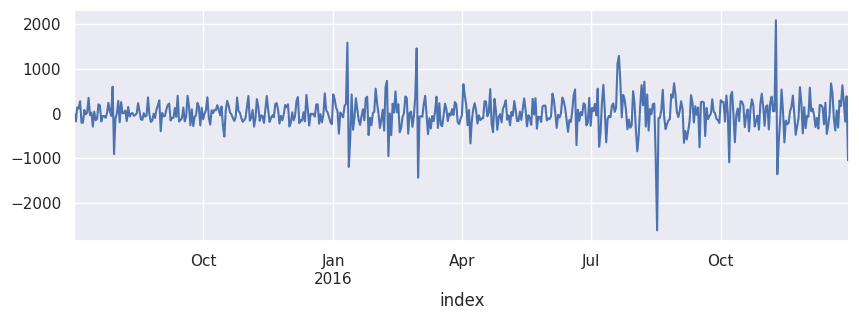

In [120]:
ts_english.diff(1).dropna().plot(figsize=(10,3))
plt.show()

In [121]:
adfuller_test(ts_english.diff(1).dropna())

The time series is stationary


The time series became stationary by just doing first-order differencing, hence d=1
Let's now look at the seasonality

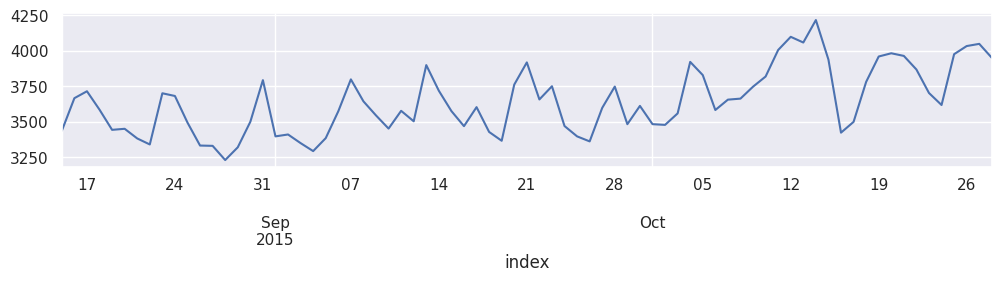

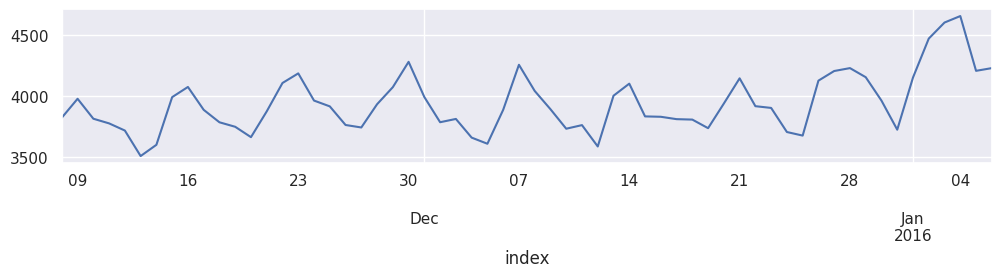

In [122]:
ts_english[45:120].plot(figsize=(12,2))
plt.show()
ts_english[130:190].plot(figsize=(12,2))
plt.show()

- Observing the above two plots, we can conclude that there is a seasonality of 7 days. So s=7
- The peaks and troughs repeat every 7 days

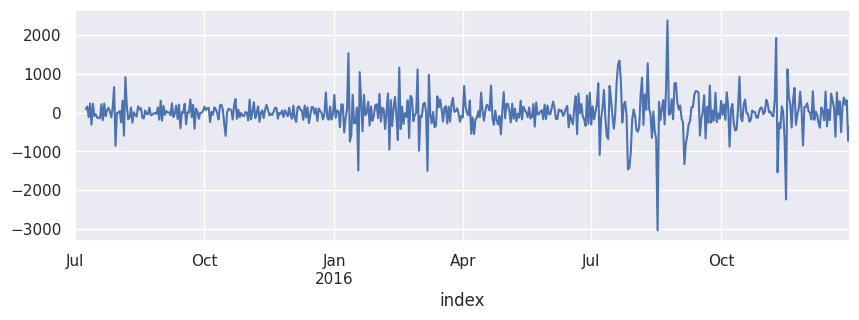

In [123]:
ts_english.diff(1).diff(7).plot(figsize=(10,3))
plt.show()

In [124]:
adfuller_test(ts_english.diff(1).diff(7).dropna())

The time series is stationary


After removing the trend(and if required, seasonality) manually, the Augmented Dickey-Fuller test says that the time series is stationary

## 4.3. Auto de-composition
We had done manual decomposition above but there is a statsmodel library to decompose time series

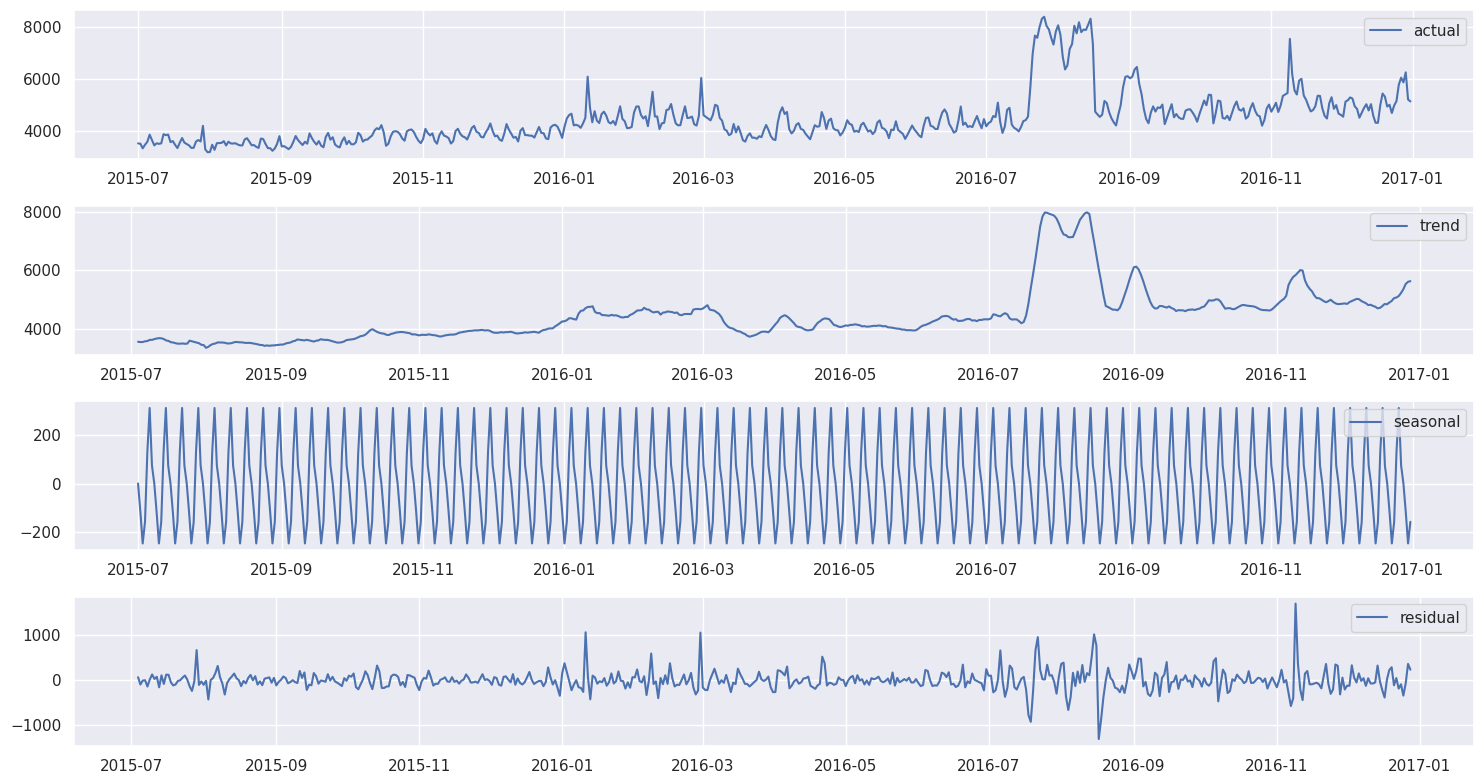

In [125]:
decom = seasonal_decompose(ts_english)
ts_english_trend = decom.trend
ts_english_seas = decom.seasonal
ts_english_res = decom.resid
plt.figure(figsize=(15,8))
plt.subplot(411)
plt.plot(ts_english, label='actual')
plt.legend()
plt.subplot(412)
plt.plot(ts_english_trend, label='trend')
plt.legend()
plt.subplot(413)
plt.plot(ts_english_seas, label='seasonal')
plt.legend()
plt.subplot(414)
plt.plot(ts_english_res, label='residual')
plt.legend()
plt.tight_layout()
plt.show()

## 4.4. ACF and PACF plots
- The ACF plot shows the correlation of a time series with itself at different lags, while the PACF plot shows the correlation of a time series with itself at different lags, after removing the effects of the previous lags
- The ACF plot can be used to identify the order of an AR model. The order of an AR model is the number of lags that are included in the model. The ACF plot will show spikes at the lags that are included in the model.
- The PACF plot can be used to identify the order of an MA model. The order of an MA model is the number of lags that are included in the model. The PACF plot will show spikes at the lags that are included in the model

Note: Stationary data needs to be provided to the ACF and PACF plots

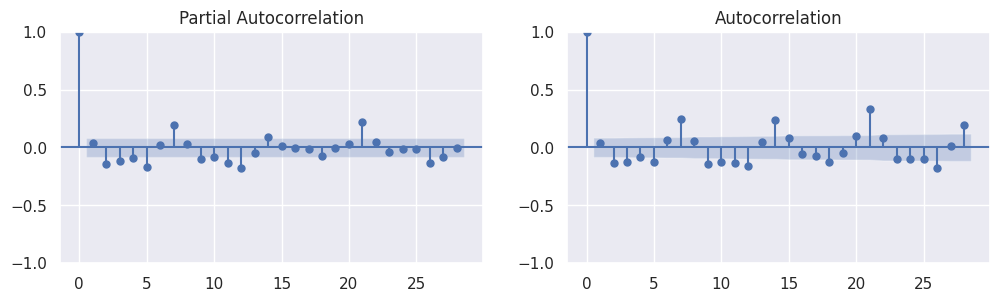

In [126]:
fig, axs = plt.subplots(1,2, figsize=(12, 3))
plot_pacf(ax=axs[0], x=ts_english.diff(1).dropna())
plot_acf(ax=axs[1], x=ts_english.diff(1).dropna())
plt.show()

- From the PACF plot, we can see that there are 3 significant lags, at 5, 7 and 21. So P=1,2 or 3
- From the ACF plot, we can see that there are 3 significant lags, at 7, 14 and 21. So Q=1,2 or 3
- From the PACF plot, the cut-off is right from lag 0 and same for ACF plot. hence, p and q = 0 or 1

# 5. Model building and Evaluation

In [127]:
# Creating a function to print values of all these metrics.
def performance(actual, predicted, print_metrics=True):
    MAE = round(mae(actual, predicted), 3)
    RMSE = round(mse(actual, predicted)**0.5, 3)
    MAPE = round(mape(actual, predicted), 3)
    if(print_metrics==True):
        print('MAE :', MAE)
        print('RMSE :', RMSE)
        print('MAPE:', MAPE)
    return MAE, RMSE, MAPE

## 5.1. ARIMA model

In [128]:
TS = ts_english.copy(deep=True)

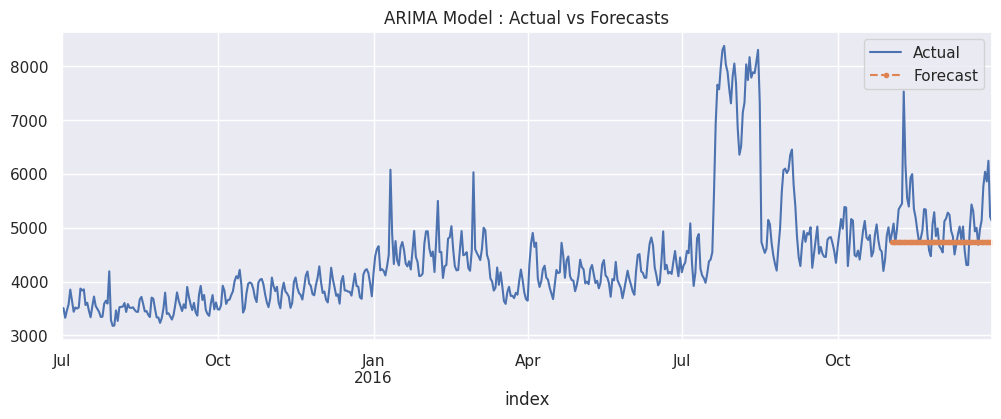

MAE : 477.636
RMSE : 672.778
MAPE: 0.086


In [129]:
n_forecast = 60
model = ARIMA(TS[:-n_forecast], order = (0,1,0))
model = model.fit()
predicted = model.forecast(steps= n_forecast, alpha = 0.05)
plt.figure(figsize=(12,4))
TS.plot(label = 'Actual')
predicted.plot(label = 'Forecast', linestyle='dashed', marker='.')
plt.legend(loc="upper right")
plt.title('ARIMA Model : Actual vs Forecasts')
plt.show()
(_,_,_) = performance(TS.values[-n_forecast:], predicted.values, print_metrics=True)

### Insight
The model is not doing a good job, even for different combinations of p and q

## 5.2. SARIMAX model

In [130]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

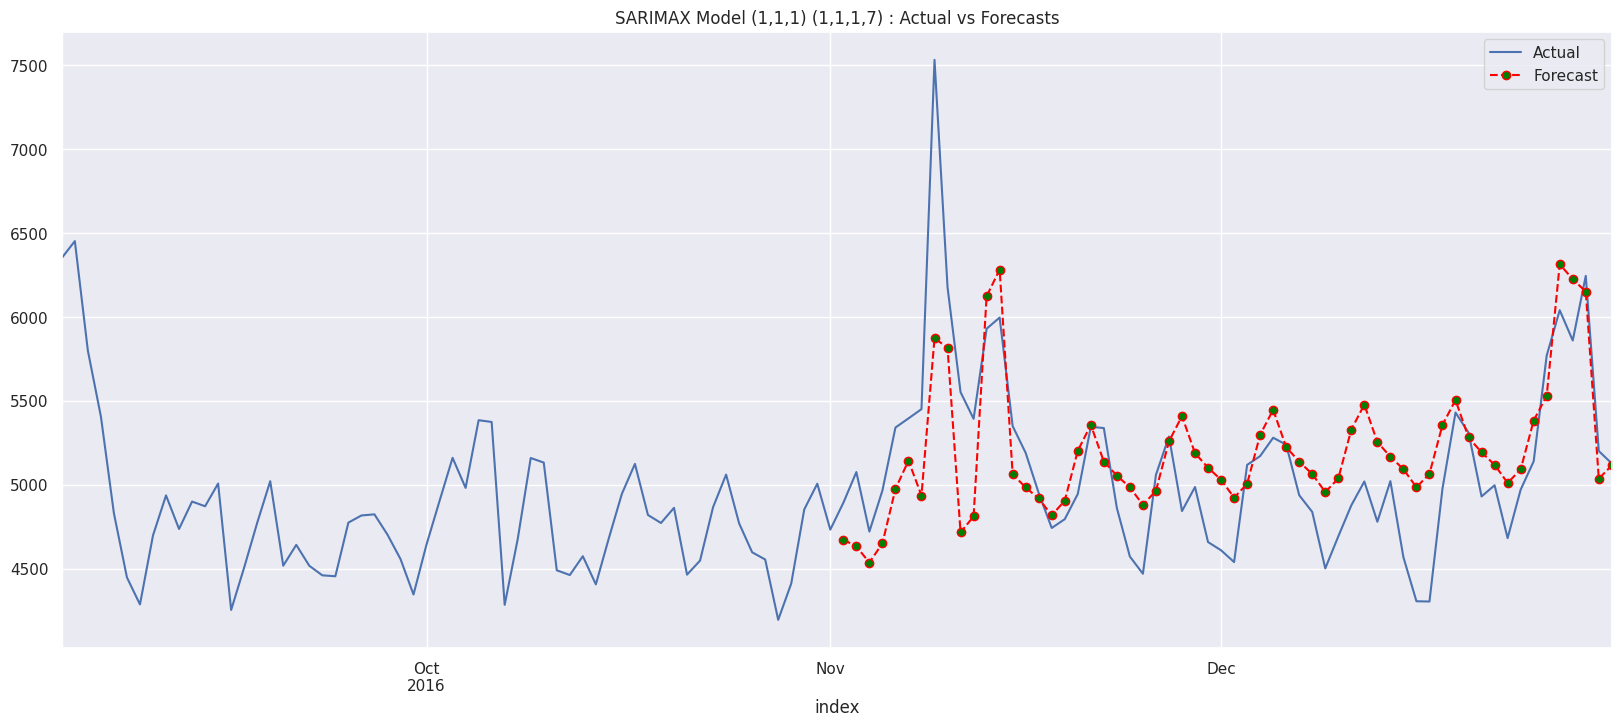

MAE : 306.417
RMSE : 399.016
MAPE: 0.06


In [131]:
exog = exog_en['Exog'].to_numpy()
p,d,q,P,D,Q,s = 1,1,1,1,1,1,7
n_forecast = 60
model = SARIMAX(TS[:-n_forecast], order =(p,d,q), seasonal_order=(P, D, Q, s), exog = exog[:-n_forecast], initialization='approximate_diffuse')
model_fit = model.fit()
#Creating forecast for last n-values
model_forecast = model_fit.forecast(n_forecast, dynamic = True, exog = pd.DataFrame(exog[-n_forecast:]))

plt.figure(figsize = (20,8))
TS[-120:].plot(label = 'Actual')
model_forecast[-120:].plot(label = 'Forecast', color = 'red', linestyle='dashed', marker='o',markerfacecolor='green')
plt.legend(loc="upper right")
plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts')
plt.show()

(_,_,_) = performance(TS.values[-n_forecast:], model_forecast.values, print_metrics=True)

### Insight
SARIMAX model is doing a significantly better job. We need to search for the right order values

In [132]:
def SARIMAX_search(TS, forecast, p_list, d_list, q_list, P_list, D_list, Q_list, s_list, exog=[]):
    counter = 0
    #perf_df = pd.DataFrame(columns=['serial', 'pdq', 'PDQs', 'mape', 'rmse', 'aic', 'bic'])
    perf_df = pd.DataFrame(columns=['serial', 'pdq', 'PDQs', 'mape', 'rmse'])

    for p in p_list:
        for d in d_list:
            for q in q_list:
                for P in P_list:
                    for D in D_list:
                        for Q in Q_list:
                            for s in s_list:
                                try:
                                    model = SARIMAX(TS[:-n_forecast], order =(p,d,q), seasonal_order=(P, D, Q, s), exog = exog[:-n_forecast], initialization='approximate_diffuse')
                                    model_fit = model.fit()
                                    model_forecast = model_fit.forecast(n_forecast, dynamic = True, exog = pd.DataFrame(exog[-n_forecast:]))
                                    MAE, RMSE, MAPE = performance(TS.values[-n_forecast:], model_forecast.values, print_metrics=False)
                                    counter += 1
                                    #list_row = [counter, (p,d,q), (P,D,Q,s), MAPE, RMSE, model_fit.aic, model_fit.bic]
                                    list_row = [counter, (p,d,q), (P,D,Q,s), MAPE, RMSE]
                                    perf_df.loc[len(perf_df)] = list_row
                                    print(f'Combination {counter} out of {(len(p_list)*len(d_list)*len(q_list)*len(P_list)*len(D_list)*len(Q_list)*len(s_list))}')
                                except:
                                    continue
    return perf_df

In [133]:
if 0:
    TS = ts_english.copy(deep=True)
    n_forecast = 60
    p_list = [0,1]
    d_list = [1]
    q_list = [0,1]
    P_list = [2,3]
    D_list = [1]
    Q_list = [2,3]
    s_list = [7]
    exog = exog_en['Exog'].to_numpy()
    perf_df = SARIMAX_search(TS, n_forecast, p_list, d_list, q_list, P_list, D_list, Q_list, s_list, exog)
    perf_df.sort_values(['mape', 'rmse'])

After the above experiment, p,d,q,P,D,Q,s = 1,1,1,2,1,3,7 were found to be best values with low mape



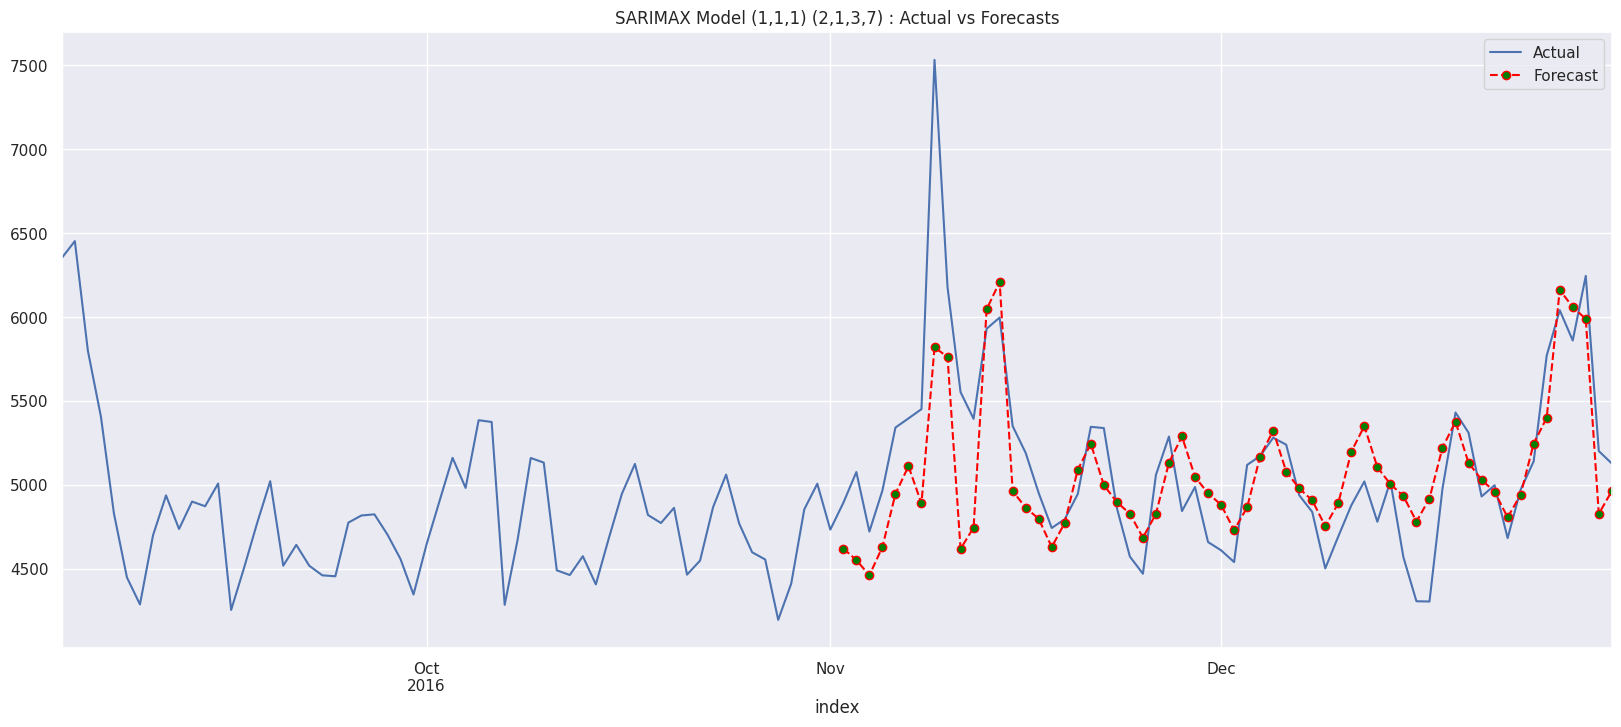

MAE : 270.513
RMSE : 373.484
MAPE: 0.051


In [134]:
exog = exog_en['Exog'].to_numpy()
p,d,q,P,D,Q,s = 1,1,1,2,1,3,7
n_forecast = 60
model = SARIMAX(TS[:-n_forecast], order =(p,d,q), seasonal_order=(P, D, Q, s), exog = exog[:-n_forecast], initialization='approximate_diffuse')
model_fit = model.fit()
#Creating forecast for last n-values
model_forecast = model_fit.forecast(n_forecast, dynamic = True, exog = pd.DataFrame(exog[-n_forecast:]))

plt.figure(figsize = (20,8))
TS[-120:].plot(label = 'Actual')
model_forecast[-120:].plot(label = 'Forecast', color = 'red', linestyle='dashed', marker='o',markerfacecolor='green')
plt.legend(loc="upper right")
plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts')
plt.show()

(_,_,_) = performance(TS.values[-n_forecast:], model_forecast.values, print_metrics=True)

### Insight
There is good improvement in the SARIMAX model after tuning the parameters
# 5.4. Facebook Prophet

In [135]:
#!pip install pystan~=2.14
#!pip install prophet

In [136]:
TS = ts_english.copy(deep=True).reset_index()
TS = TS[['index', 'English']]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
exog = exog_en['Exog']
TS['exog'] = exog.values
TS.tail()

,ds,y,exog
545,2016-12-27,6040.680728,1
546,2016-12-28,5860.227559,1
547,2016-12-29,6245.127510,1
548,2016-12-30,5201.783018,0
549,2016-12-31,5127.916418,0


In [137]:
from prophet import Prophet
my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.add_regressor('exog')
n_forecast = 60
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
future_dates['exog'] = TS['exog']
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/1981j7ue.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/xvkbfiri.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59688', 'data', 'file=/tmp/tmp60nnt481/1981j7ue.json', 'init=/tmp/tmp60nnt481/xvkbfiri.json', 'output', 'file=/tmp/tmp60nnt481/prophet_modelry30s3wd/prophet_model-20250410133631.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 287.417
RMSE : 441.959
MAPE: 0.06


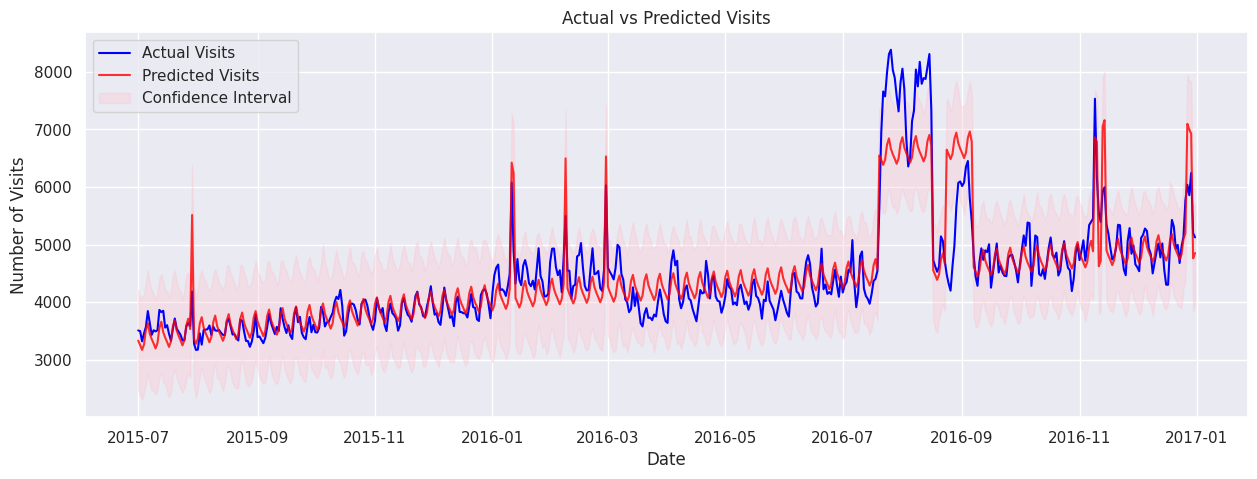

In [138]:
# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

##Insight
Phropet is doing an incredible job capturing the trend and unusual peaks. It is also capturing the seasonality very well

# 5.5. Comparison
## 5.5.1 Chinese

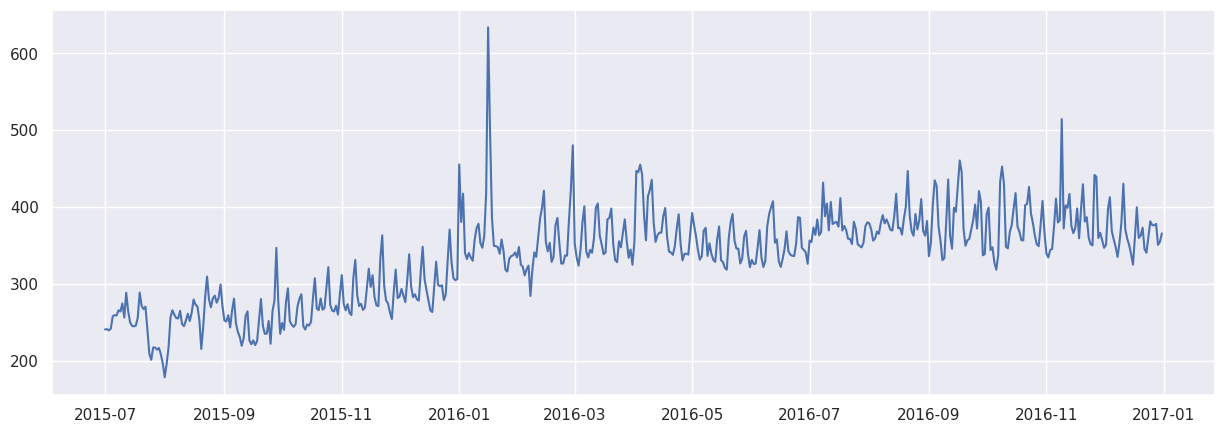

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/gw75ejej.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/a23wey3e.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42479', 'data', 'file=/tmp/tmp60nnt481/gw75ejej.json', 'init=/tmp/tmp60nnt481/a23wey3e.json', 'output', 'file=/tmp/tmp60nnt481/prophet_modelg8otr9w4/prophet_model-20250410133631.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 19.353
RMSE : 28.703
MAPE: 0.058


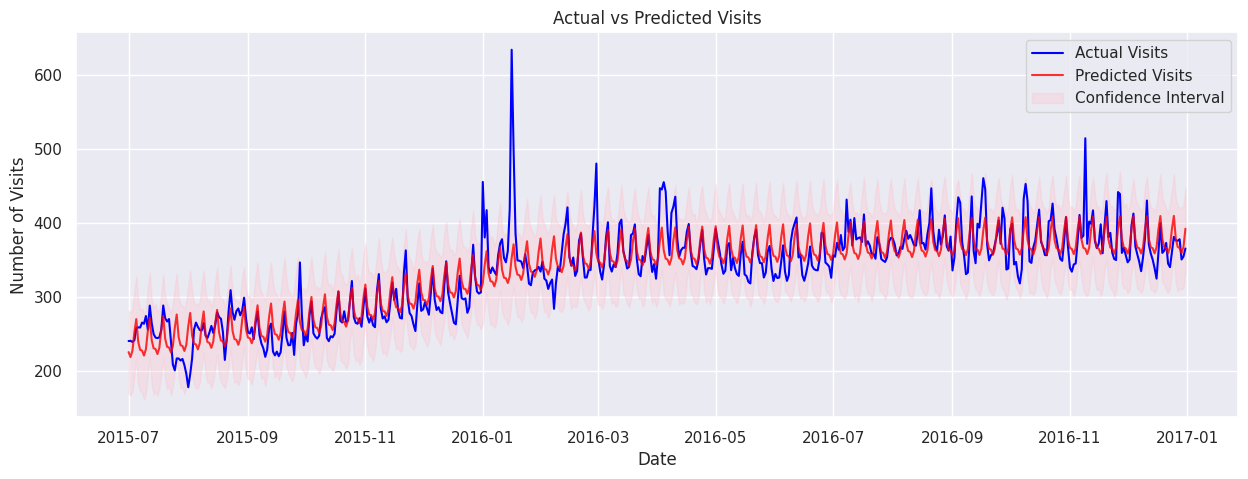

In [139]:
lang = 'Chinese'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

## 5.5.2 French

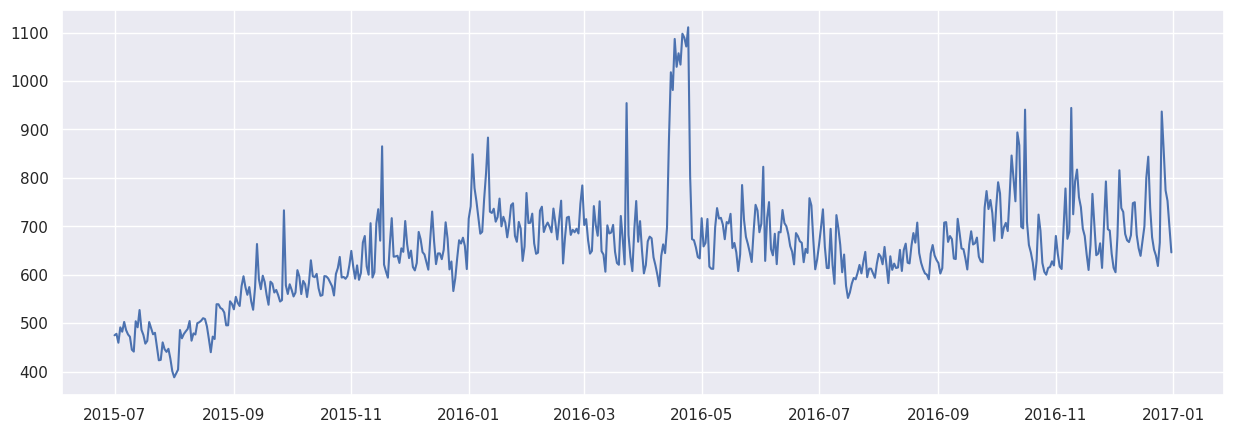

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/gudpxjvt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/vxl53wio.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48358', 'data', 'file=/tmp/tmp60nnt481/gudpxjvt.json', 'init=/tmp/tmp60nnt481/vxl53wio.json', 'output', 'file=/tmp/tmp60nnt481/prophet_modelruwjo_lz/prophet_model-20250410133632.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 42.038
RMSE : 68.864
MAPE: 0.061


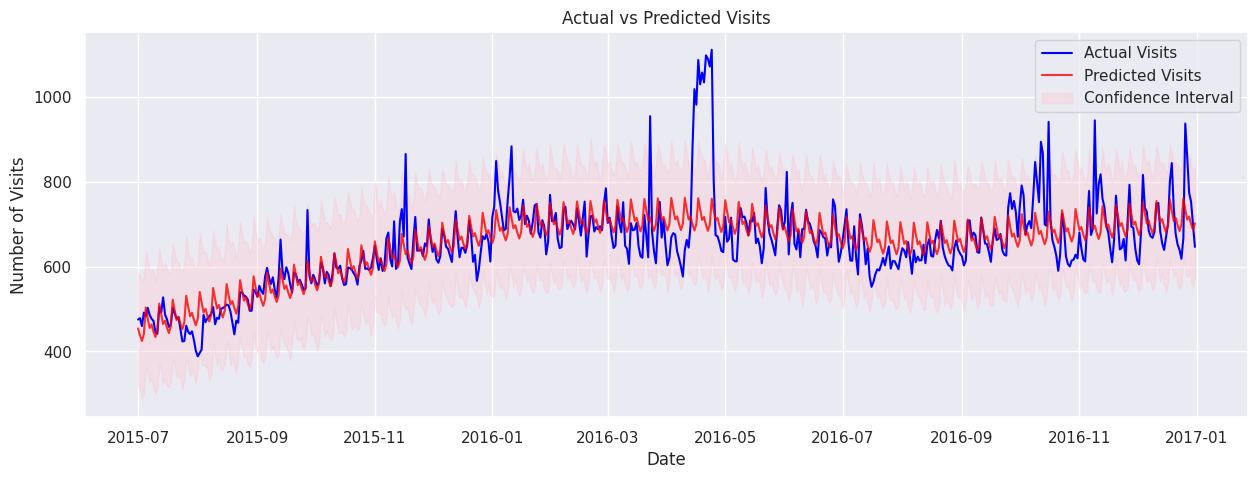

In [140]:
lang = 'French'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

## 5.5.3 German

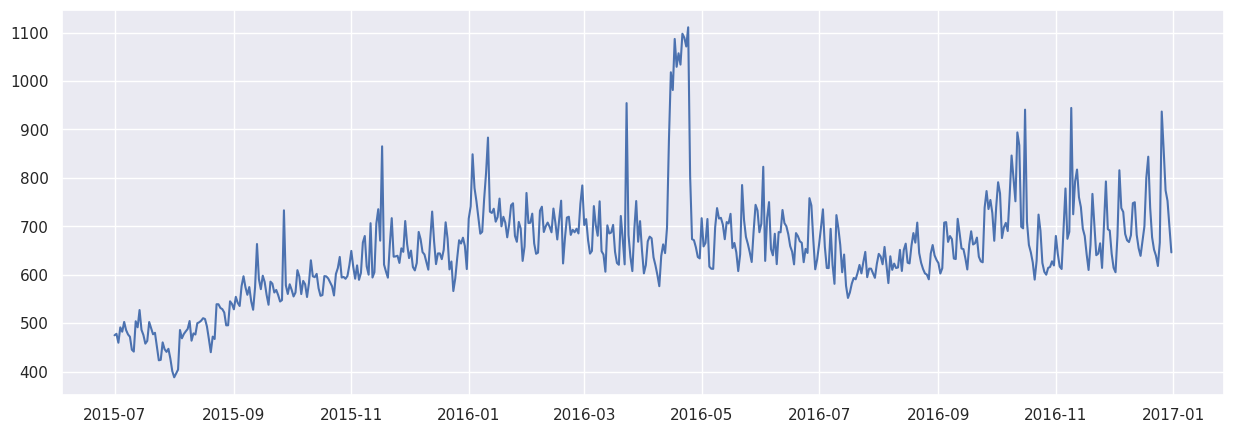

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/519jf8u0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/uyfh5oq3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67861', 'data', 'file=/tmp/tmp60nnt481/519jf8u0.json', 'init=/tmp/tmp60nnt481/uyfh5oq3.json', 'output', 'file=/tmp/tmp60nnt481/prophet_modelj0nz9vmr/prophet_model-20250410133633.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 42.038
RMSE : 68.864
MAPE: 0.061


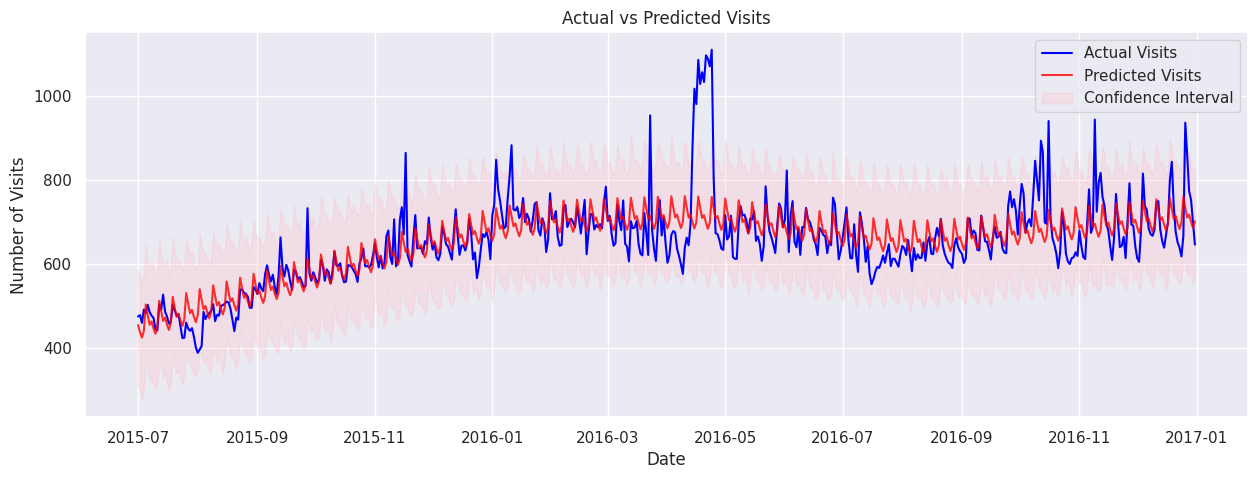

In [141]:
ang = 'German'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

## 5.5.4 Japanese

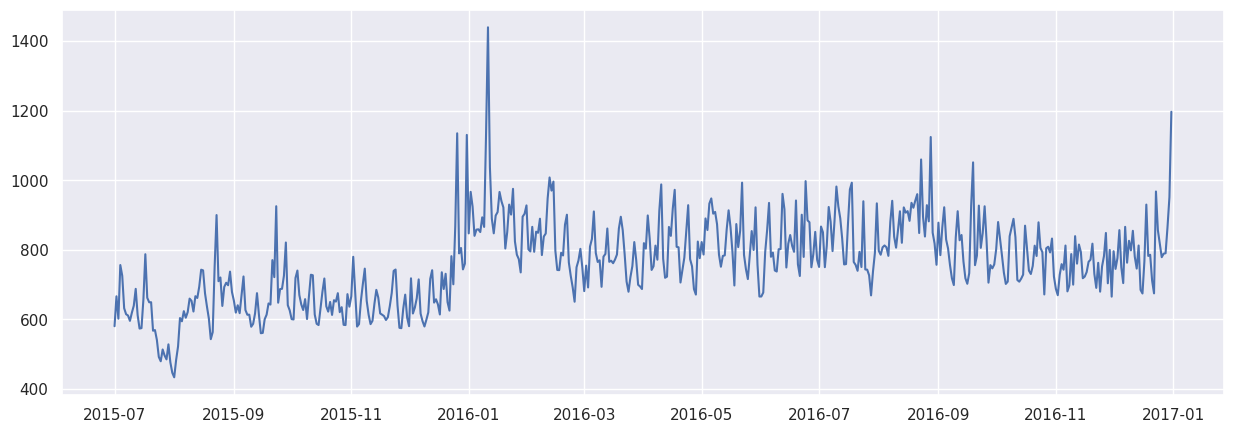

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/u4uit3uo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/x9jwxywl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40437', 'data', 'file=/tmp/tmp60nnt481/u4uit3uo.json', 'init=/tmp/tmp60nnt481/x9jwxywl.json', 'output', 'file=/tmp/tmp60nnt481/prophet_model19_rqat0/prophet_model-20250410133634.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 61.153
RMSE : 84.062
MAPE: 0.08


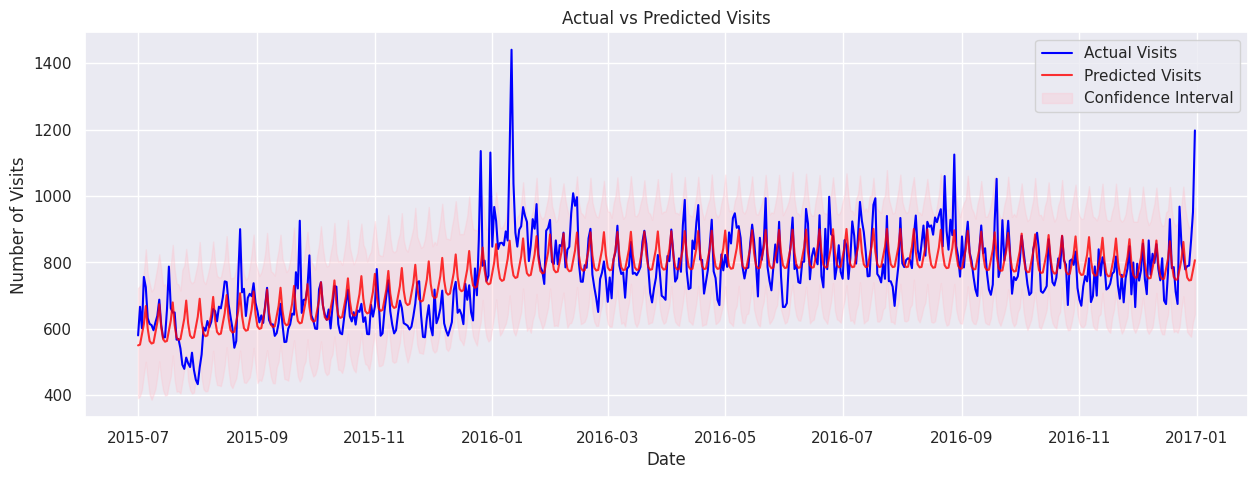

In [142]:
lang = 'Japanese'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

## 5.5.5 Russian

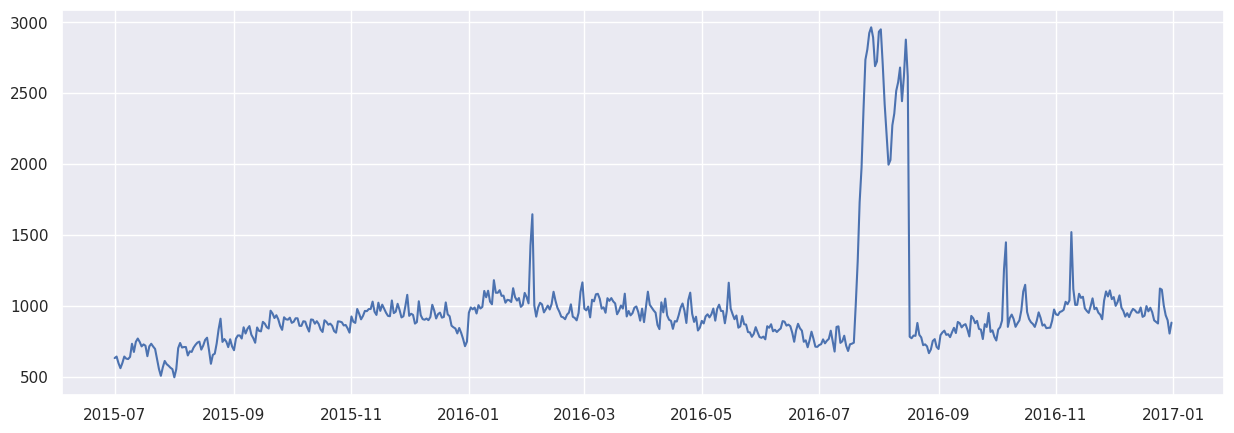

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/vgt3fb4w.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/h942uglz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16529', 'data', 'file=/tmp/tmp60nnt481/vgt3fb4w.json', 'init=/tmp/tmp60nnt481/h942uglz.json', 'output', 'file=/tmp/tmp60nnt481/prophet_modelbebt1qve/prophet_model-20250410133634.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 185.326
RMSE : 353.315
MAPE: 0.169


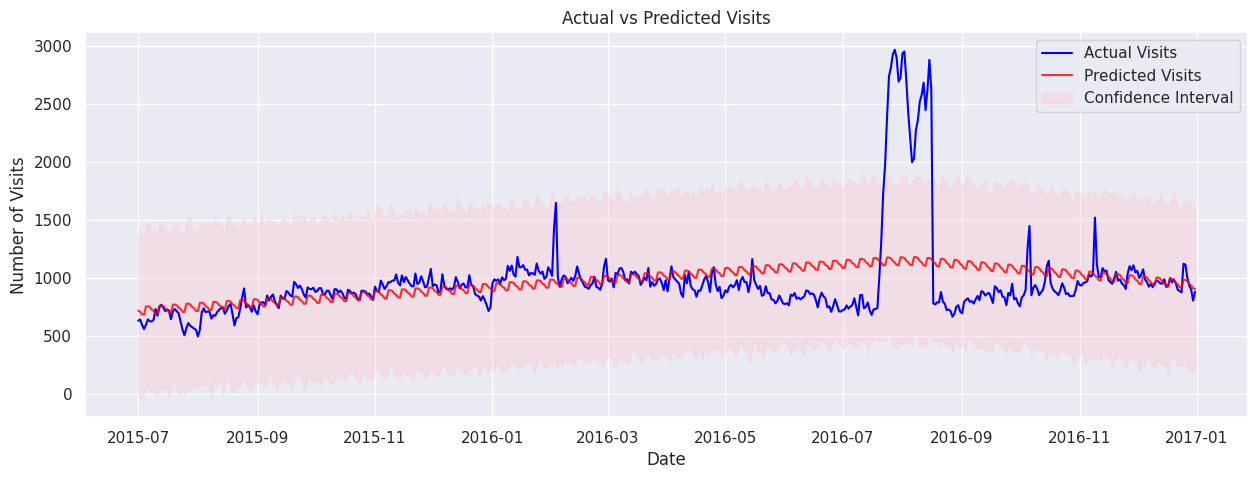

In [143]:
lang = 'Russian'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

## 5.5.6 Spanish

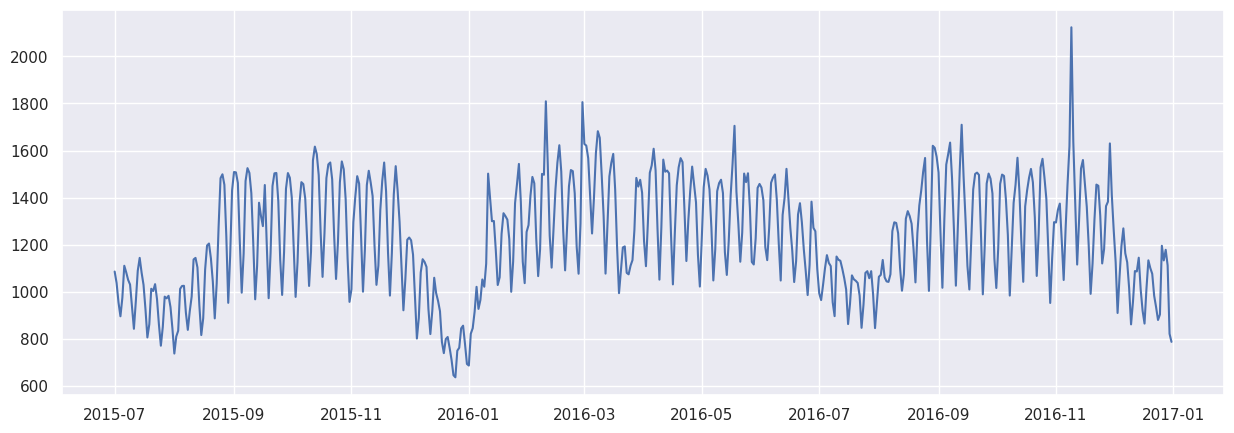

DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/pv2cu2uk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp60nnt481/bxpz69ci.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24295', 'data', 'file=/tmp/tmp60nnt481/pv2cu2uk.json', 'init=/tmp/tmp60nnt481/bxpz69ci.json', 'output', 'file=/tmp/tmp60nnt481/prophet_model0igci2l4/prophet_model-20250410133635.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:36:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:36:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE : 134.492
RMSE : 173.774
MAPE: 0.118


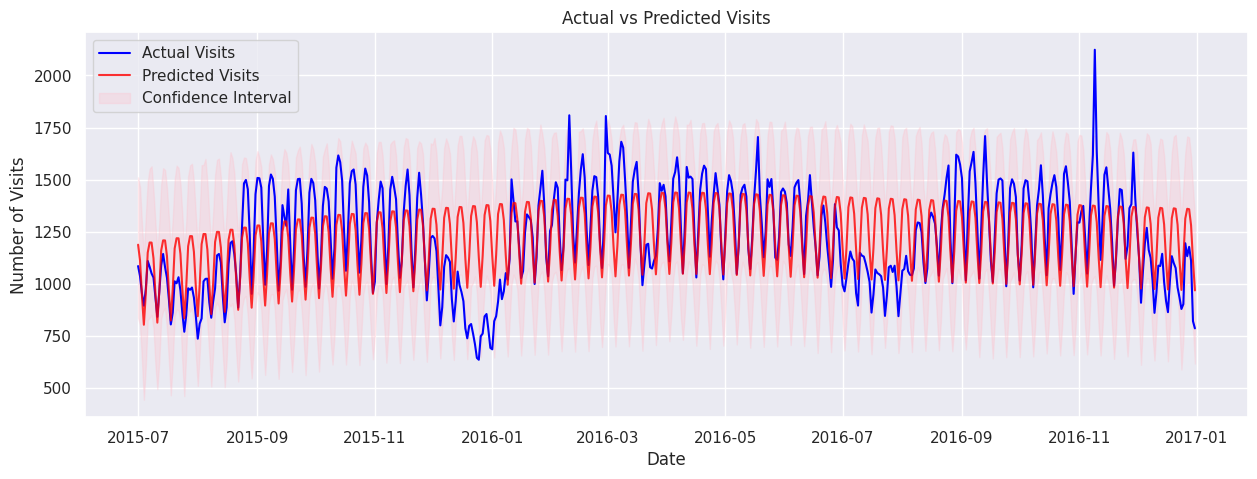

In [144]:
lang = 'Spanish'
TS = df_agg[lang].copy(deep=True)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(TS.index, TS)
plt.show()

TS = TS.reset_index()
TS = TS[['index', lang]]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
TS.tail()

my_model = Prophet(interval_width=0.95, daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
my_model.fit(TS)
future_dates = my_model.make_future_dataframe(periods=0)
forecast = my_model.predict(future_dates)

# Step 6: Merge Predictions with Actual Data
TS['yhat'] = forecast['yhat']  # The predicted values (yhat) from Prophet
TS['yhat_upper'] = forecast['yhat_upper']  # Upper bound of the confidence interval
TS['yhat_lower'] = forecast['yhat_lower']  # Lower bound of the confidence interval

(_,_,_) = performance(TS['y'], TS['yhat'], print_metrics=True)

# Plot actual vs predicted visits
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='Actual Visits', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='Predicted Visits', color='red', alpha=0.8)
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink', alpha=0.3, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.title('Actual vs Predicted Visits')
plt.legend()
plt.show()

# 6. Result Interpretations
- There are 7 known language pages in the dataset - English, Japanese, German, French, Chinese, Russian and Spanish
- English has the maximum number of pages, 16.62%. This is excpected as the maximum people speak English
- Decomposition helps in understanding the underlying trend, seasonality and error(residual) in the time series data.
- As per the analysis done on English language time series data, a differencing of 1 gives a stationary series. This is also tested using Augmented Dickey-Fuller test
- As per the exogenous variable given, the visits to the English page has an unusual peak whenever the exogenous variable is 1
- The performance of AdEase will be effected by events or campaings. AdEase can use the Prophet model along with exogenous variable to improve their predictions
- Without the exogenous variable, it becomes impossible to make accurate predictions. This is demonstarted by the plots of other languages which do not have exogneous variable
<br>
The main difference between ARIMA, SARIMA and SARIMAX is:
- ARIMA is used for modeling non-seasonal time series data with trends and autocorrelations
- SARIMA extends ARIMA by explicitly modeling seasonality in the time series. It’s useful when the time series exhibits seasonal patterns (e.g., monthly or yearly cycles).
- SARIMAX is an extension of SARIMA that includes exogenous variables (external factors) in the model. It models both seasonal and non-seasonal components, while also incorporating the effect of other external (exogenous) variables that may influence the time series.

In [145]:
print('*************************************************'*2)
print('*************************************************'*2)
print('*************************************************'*2)
print('*************************************************'*2)


**************************************************************************************************
**************************************************************************************************
**************************************************************************************************
**************************************************************************************************
